# Importar librerias

In [40]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np

In [41]:
SUP, TINTA, TINTA2, MUTED, GRID, EJE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
AZUL, GRIS = "#2a78d6", "#c9c8c1"

sns.set_theme(style="white", context="talk")
plt.rcParams.update({
    "figure.facecolor": SUP, "axes.facecolor": SUP, "savefig.facecolor": SUP,
    "figure.dpi": 130, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.titlesize": 13, "axes.titleweight": "semibold", "axes.titlecolor": TINTA,
    "axes.titlelocation": "left", "axes.titlepad": 14,
    "axes.labelsize": 10, "axes.labelcolor": TINTA2,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "axes.edgecolor": EJE, "axes.linewidth": 0.8,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.grid": False, "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 9.5,
    "lines.linewidth": 2, "lines.markersize": 8,
})

# Definir ubicación del archivo

In [42]:
FILE_PATH = Path().cwd() / "data" / "Apartamentos.csv"

In [43]:
df = pd.read_csv(FILE_PATH)

In [44]:
df.head()

,fecha,precio(millones de pesos),area(mt2),zona,estrato,habitaciones,baños,balcon,parqueadero,administracion (millones de pesos),avaluo (millones de pesos),remodelado
0,13/02/23,79.0,43.16,norte,3,3,1,si,si,0.050,14.923002,no
1,2/05/23,93.0,56.92,norte,2,2,1,si,si,0.069,27.000000,si
2,17/01/23,100.0,66.40,norte,3,2,2,no,no,0.000,15.738427,no
3,15/08/23,123.0,61.85,norte,2,3,2,si,si,0.130,27.000000,no
4,11/08/23,135.0,89.80,norte,4,3,2,si,no,0.000,39.567000,si


# 1. Tareas de Limpieza

In [45]:
# filas y columnas del archivo
df.shape

(694, 12)

In [46]:
# confirmar que no haya duplicados
df.duplicated().sum()

np.int64(0)

In [47]:
# verificar tipos de datos
df.dtypes

fecha                                     str
precio(millones de pesos)             float64
area(mt2)                             float64
zona                                      str
estrato                                 int64
habitaciones                            int64
baños                                   int64
balcon                                    str
parqueadero                               str
administracion (millones de pesos)    float64
avaluo (millones de pesos)            float64
remodelado                                str
dtype: object

In [48]:
# Esta fecha no existe, debe ser reemplazada
df.query("fecha == '29/02/23'")

,fecha,precio(millones de pesos),area(mt2),zona,estrato,habitaciones,baños,balcon,parqueadero,administracion (millones de pesos),avaluo (millones de pesos),remodelado
431,29/02/23,185.0,70.0,aburra sur,4,3,2,si,si,0.200,107.000,si
650,29/02/23,265.0,128.0,laureles,5,3,3,si,si,0.187,135.422,si


In [49]:
# convertir fecha de str a fecha
df = (
    df
    .assign(
        fecha=lambda _df: pd.to_datetime(_df["fecha"].str.replace("29/02/23", "28/02/23"), format="%d/%m/%y")
    )
    # para facilidad, se renombraran variables
    .rename(
        columns={
            "precio(millones de pesos)": "precio",
            "area(mt2)": "area",
            "administracion (millones de pesos)": "admon",
            "avaluo (millones de pesos)": "avaluo"
        }
    )
)

In [50]:
df.dtypes

fecha           datetime64[us]
precio                 float64
area                   float64
zona                       str
estrato                  int64
habitaciones             int64
baños                    int64
balcon                     str
parqueadero                str
admon                  float64
avaluo                 float64
remodelado                 str
dtype: object

In [51]:
# Ahora se validara los distintos tipos para variable tipo str
df["zona"].value_counts()
# observamos que hay discrepancias, valores con espacios, minusculas, mayusculas. se procede a estandarizar

zona
poblado            253
aburra sur         167
laureles            68
belen guayabal      65
occidente           62
centro              37
norte               10
POBLADO              7
Poblado              6
OCCIDENTE            3
Occidente            3
poblado              2
aburra s             2
belen  guayabal      2
Laureles             2
laureles             2
 occidente           1
  centro             1
LAURELES             1
Name: count, dtype: int64

In [52]:
df["zona"] = (   
    df["zona"]
    # remover espacios extras
    .str.strip()
    # convertir a minusculas
    .str.lower()
    # reemplazar
    .str.replace("belen  guayabal", "belen guayabal")
    .str.replace(r"^aburra s$", "aburra sur", regex=True)
)

# se valida el fix
df["zona"].value_counts()

zona
poblado           268
aburra sur        169
laureles           73
occidente          69
belen guayabal     67
centro             38
norte              10
Name: count, dtype: int64

In [53]:
df["balcon"].value_counts()

balcon
si    509
no    185
Name: count, dtype: int64

In [54]:
df["parqueadero"].value_counts()

parqueadero
si    568
no    126
Name: count, dtype: int64

In [55]:
df["remodelado"].value_counts()

remodelado
si    592
no    102
Name: count, dtype: int64

In [56]:
# Ahora revisemos datos faltantes
df.isna().sum()

fecha           0
precio          2
area            0
zona            0
estrato         0
habitaciones    0
baños           0
balcon          0
parqueadero     0
admon           1
avaluo          0
remodelado      0
dtype: int64

In [57]:
df["precio"] =  df["precio"].fillna(
    df.groupby(["estrato", "zona", "habitaciones"])["precio"].transform("median")
)
df["admon"] =  df["admon"].fillna(
    df.groupby(["estrato", "zona", "habitaciones"])["admon"].transform("median")
)

In [58]:
# Ahora revisemos nuevamente datos faltantes
df.isna().sum()

fecha           0
precio          0
area            0
zona            0
estrato         0
habitaciones    0
baños           0
balcon          0
parqueadero     0
admon           0
avaluo          0
remodelado      0
dtype: int64

# 2. Oferta de apartamentos por zona

In [59]:
apartamentos_por_zona = df["zona"].value_counts(sort=True, ascending=False)
apartamentos_por_zona

zona
poblado           268
aburra sur        169
laureles           73
occidente          69
belen guayabal     67
centro             38
norte              10
Name: count, dtype: int64

In [60]:
sns.set_theme("talk")
sns.set_palette("Paired")

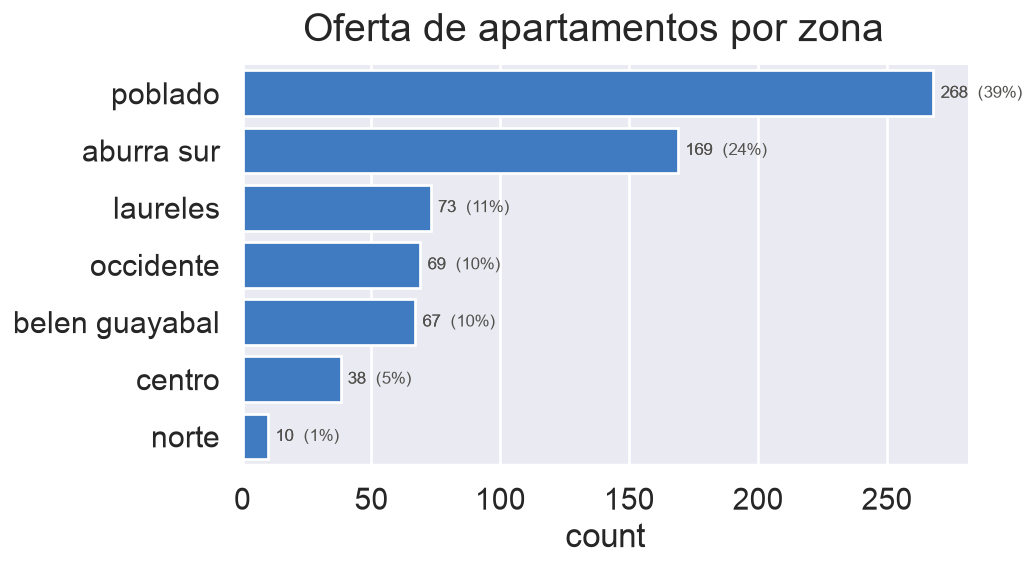

In [61]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))

g = sns.countplot(
    data=df,
    y="zona",
    order=df["zona"].value_counts().index,
    color="#2a78d6",
    ax=ax
    )

ax.bar_label(ax.containers[0], padding=4, color="#52514e", fontsize=9.5)
g.figure.suptitle("Oferta de apartamentos por zona")
ax.set_ylabel("")
sns.despine(ax=ax, left=True, bottom=False)
etiquetas = [f"{v}  ({v/len(df):.0%})" for v in apartamentos_por_zona]
ax.bar_label(
    ax.containers[0],
    labels=etiquetas,
    padding=4,
    color="#52514e",
    fontsize=9.5
    )
plt.show()


# 3. Precio promedio del metro cuadrado por zona

In [62]:
# necesitamos calcular el precio por metro cuadrado
df["precio_m2"] = df["precio"] / df["area"]

In [63]:
precio_promedio_m2_por_zona = (
    df
    .groupby("zona")
    .agg(precio_promedio_m2 = ("precio_m2", "mean"))
    .reset_index()
    .sort_values(by="precio_promedio_m2", ascending=False)
)
precio_promedio_m2_por_zona

,zona,precio_promedio_m2
6,poblado,3.018753
0,aburra sur,2.480120
3,laureles,2.385277
5,occidente,2.112130
1,belen guayabal,2.088670
4,norte,1.999246
2,centro,1.794107


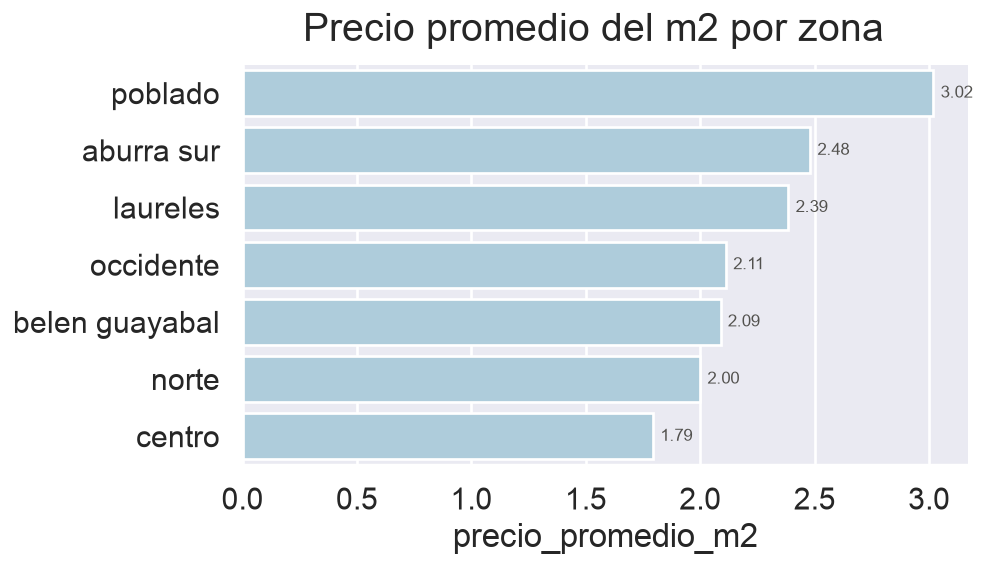

In [64]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))

g = sns.barplot(
    data=precio_promedio_m2_por_zona,
    x="precio_promedio_m2",
    y="zona",
    ax=ax
)
g.figure.suptitle("Precio promedio del m2 por zona")
ax.set_ylabel("")
sns.despine(ax=ax, left=True, bottom=False)
etiquetas = [f"{v:.2f}" for v in precio_promedio_m2_por_zona["precio_promedio_m2"]]
ax.bar_label(
    ax.containers[0],
    labels=etiquetas,
    padding=4,
    color="#52514e",
    fontsize=9.5
    )
plt.show()

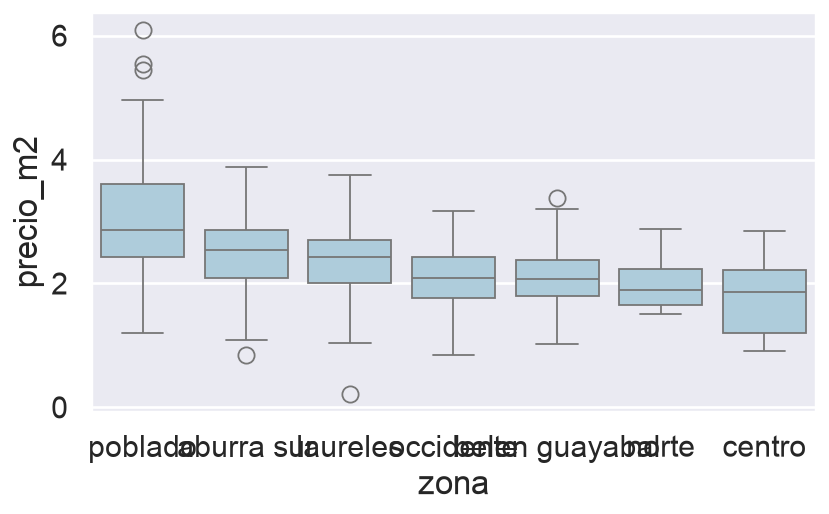

In [65]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))

g = sns.boxplot(
    x="zona",
    y="precio_m2",
    data=df,
    ax=ax,
    order=df.groupby("zona")["precio_m2"].median().sort_values(ascending=False).index
)

plt.show()

# 4. Relación entre área y precio

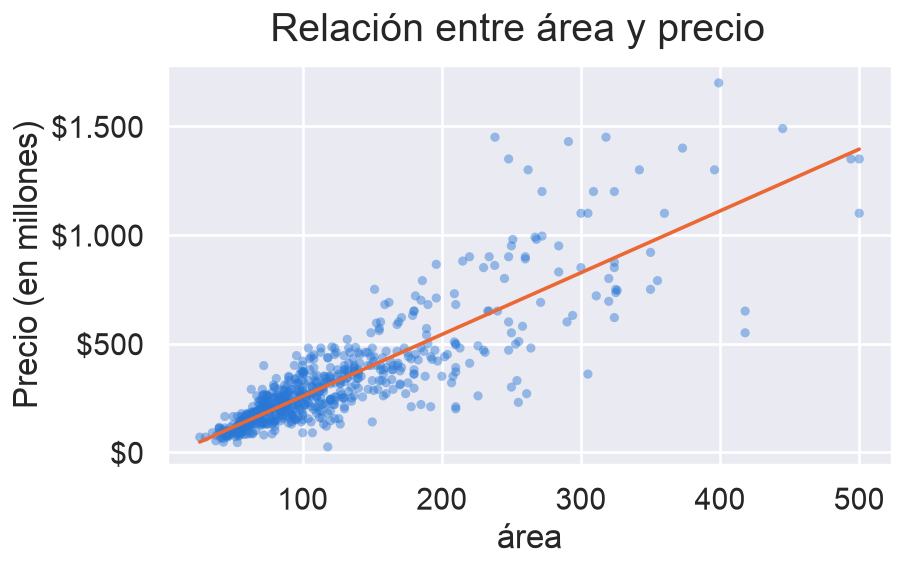

In [66]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))

g = sns.regplot(
    data=df, x="area", y="precio", ax=ax,
    scatter_kws=dict(s=26, alpha=.45, color="#2a78d6", edgecolor="none"),
    line_kws=dict(color="#eb6834", linewidth=2),
    ci=None
)
g.figure.suptitle("Relación entre área y precio")

g.set(
    xlabel="área",
    ylabel="Precio (en millones)"
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f"${v:,.0f}".replace(",", "."))
)

plt.show()

In [67]:
df["precio"].corr(df["area"])

np.float64(0.8579127011551481)

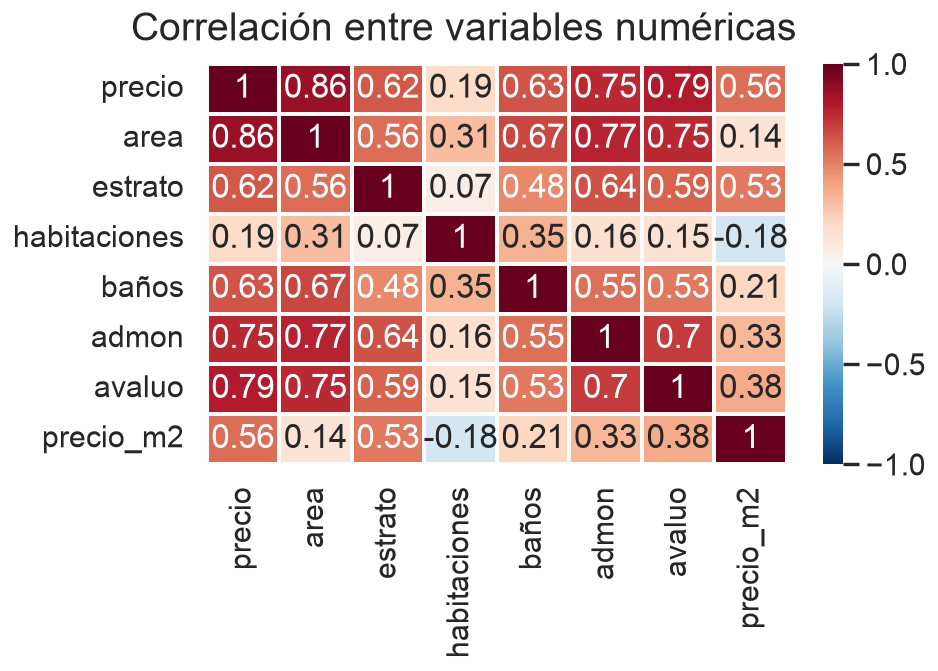

In [68]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))

g = sns.heatmap(
    np.round(df.corr(numeric_only=True), 2),
    annot=True,
    linewidths=2,
    linecolor="#fcfcfb",
    ax=ax,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0
)

g.figure.suptitle("Correlación entre variables numéricas", x = 0.4)
plt.show()

# 5. Porcentaje de avaluo por estrato

In [69]:
# anadimos el porcentaje de avaluo a cada registro
df["porcentaje_avaluo"] = df["avaluo"] / df["precio"] * 100
df[["avaluo", "precio", "porcentaje_avaluo"]].head()

,avaluo,precio,porcentaje_avaluo
0,14.923002,79.0,18.889876
1,27.000000,93.0,29.032258
2,15.738427,100.0,15.738427
3,27.000000,123.0,21.951220
4,39.567000,135.0,29.308889


In [70]:
df["porcentaje_avaluo"].mean()

np.float64(57.05096841149504)

In [71]:
avaluo_promedio_por_estrato = (
    df
    .groupby("estrato")
    .agg(porcentaje_avaluo_promedio = ("porcentaje_avaluo", "mean"))
    .reset_index()
    .sort_values(by="estrato")
)
avaluo_promedio_por_estrato

,estrato,porcentaje_avaluo_promedio
0,2,26.691457
1,3,46.333085
2,4,57.122455
3,5,63.134096
4,6,61.499467


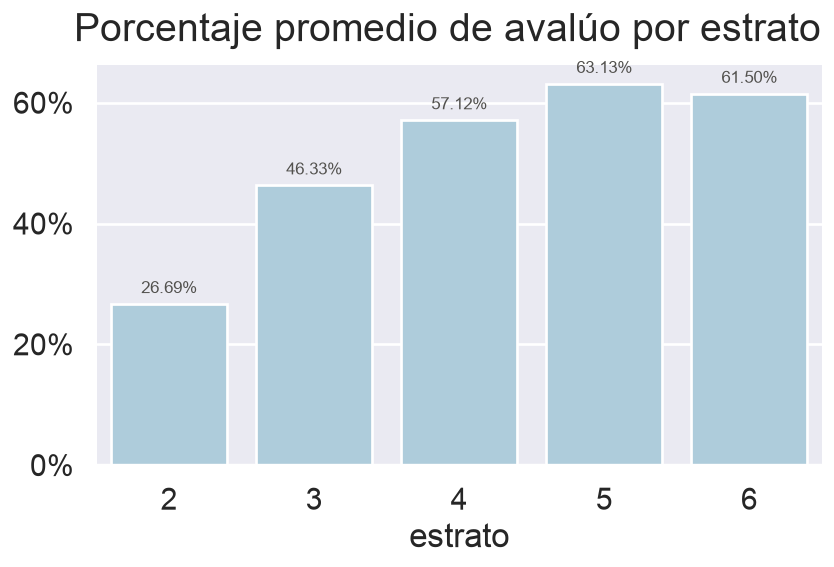

In [72]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))

g = sns.barplot(
    data=df,
    x="estrato",
    y="porcentaje_avaluo",
    ax=ax,
    errorbar=None
)
g.figure.suptitle("Porcentaje promedio de avalúo por estrato")
ax.set_ylabel("")
sns.despine(ax=ax, left=True, bottom=False)
etiquetas = [f"{v:.2f}%" for v in avaluo_promedio_por_estrato["porcentaje_avaluo_promedio"]]
ax.bar_label(
    ax.containers[0],
    labels=etiquetas,
    padding=4,
    color="#52514e",
    fontsize=9.5
    )
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f"{v:,.0f}%")
)
plt.show()